<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Linea_de_espera_dos_Servidores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <span style="color:purple;">**6.3 Sistema de línea de espera con dos servidores en serie** (libro de Ross)</span>


<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span>Analizar el comportamiento de una línea de espera en serie con dos servidores, identificando los tiempos de permanencia de los clientes en cada etapa del proceso y evaluando el desempeño global del sistema mediante simulación de eventos discretos.

Consideremos un sistema de dos servidores en el que los clientes llegan de acuerdo con un proceso Poisson no homogéneo, y supongamos que cada llegada debe ser atendida primero por el servidor 1 y, al terminar el servicio en 1, el cliente pasa al servidor 2.

Tal sistema es un sistema de cola en **tándem** o **secuencial**.

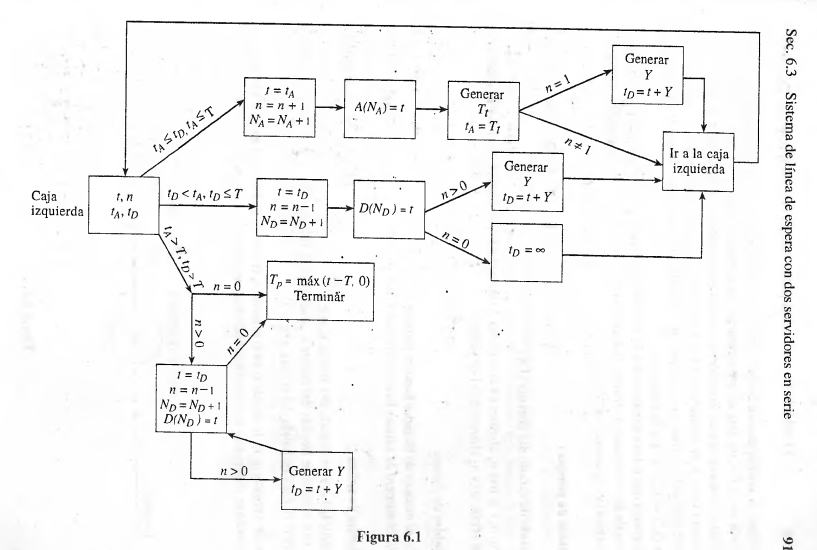

Esta línea de espera consiste en que al llegar, el cliente pasará con el servidor 1 si éste se encuentra desocupado, o se formará en la fila de éste en caso contrario. De manera análoga, cuando el cliente termine el servicio en el servidor 1, entra a servicio con el servidor 2 si éste se encuentra libre, o se formará en su fila. Después de ser atendido en el servidor 2, el cliente sale del sistema. Los tiempos de servicio en el servidor $i$ tienen la distribución $G_i$, $i = 1,2$ (véase la figura 6.2).

Suponga que estamos interesados en realizar una simulación para estudiar la distribución de las cantidades de tiempo que un cliente pasa en ambos servidores. Para esto, utilizamos las siguientes variables.



### <span style="color:green;">**Variable de tiempo $t$**</span>



### <span style="color:green;"> Variable de estado del sistema (ES)</span>

$(n_1, n_2)$: si hay $n_1$ clientes en el servidor 1 (incluyendo los formados y los que están en servicio) y $n_2$ clientes en el servidor 2.

### <span style="color:green;">Variables de conteo</span>

* $N_A$: el número de llegadas hasta el instante $t$

* $N_D$: el número de salidas hasta el instante $t$

### <span style="color:green;">**Variables de salida**</span>

* $A_1(n)$: la hora de llegada del cliente $n$, $n \geq 1$

* $A_2(n)$: la hora de llegada del cliente $n$ al servidor 2, $n \geq 1$

* $D(n)$: la hora de salida del cliente $n$, $n \geq 1$

### <span style="color:green;">**Lista de eventos**</span>

$t_A, t_1, t_2$, donde $t_A$ es la hora de la siguiente llegada y $t_i$ es la hora a la que concluye el servicio del cliente actualmente atendido por el servidor $i$, $i = 1,2$.

Si en un momento dado no se encuentra un cliente con el servidor $i$, entonces

$$
t_i = \infty, \quad i = 1,2.
$$

La lista de eventos siempre consta de las tres variables $t_A$, $t_1$, $t_2$.

In [ ]:
#Procedemos a importar las librerias necesarias
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt

Crearemos un @dataclass es un decorador de Python  (módulo dataclasses) que automatiza la creación de clases que almacenan datos. en la cual almanecenaremos las variables descritas en este proceso de línea de espera:

**Estado del sistema.**

* n1 : clientes en servidor 1
         (en cola + servicio)

* n2 : clientes en servidor 2
         (en cola + servicio)

* NA : número de llegadas

* ND : número de salidas

* t  : tiempo actual



In [ ]:
@dataclass
class EstadoSistema:
    n1: int = 0 #tipo de dato entero
    n2: int = 0

    NA: int = 0
    ND: int = 0

    t: float = 0.0 #tipo de dato flotante

Generamos tres funciones para tiempos aleatorios; supongamos que:

* Llegadas $~$ Exponencial($λ$)

* Servicio 1 $~$ Exponencial($μ₁$)

* Servicio 2 $~$ Exponencial($μ₂$)

In [ ]:
def generar_llegada(lamb):
    """
    Tiempo hasta la siguiente llegada.
    """
    return np.random.exponential(1/lamb)

In [ ]:
def generar_servicio1(mu1):
    """
    Tiempo de servicio en servidor 1.
    """
    return np.random.exponential(1/mu1)

In [ ]:
def generar_servicio2(mu2):
    """
    Tiempo de servicio en servidor 2.
    """
    return np.random.exponential(1/mu2)

Para comenzar la simulación, inicializamos las variables y la lista de eventos como sigue:

### <span style="color:green;">**Inicialización**</span>

Sean

$$
t = N_A = N_D = 0.
$$

Sea el estado del sistema

$$
ES = (0,0).
$$

Generar $T_0$ y hacer

$$
t_A = T_0,
\qquad
t_1 = t_2 = \infty.
$$

Para actualizar el sistema, nos movemos en el tiempo hasta encontrar el siguiente evento. Debemos considerar diversos casos, dependiendo del mínimo de los miembros de la lista de eventos. En lo sucesivo, $Y_i$ se refiere a una variable aleatoria con distribución $G_i$, $i=1,2$.

$$
ES=(n_1,n_2)
\qquad
LE=t_A,t_1,t_2
$$

In [ ]:
def inicializar(lamb):
    """
    Inicializa variables del sistema.
    """

    estado = EstadoSistema()

    # Próxima llegada
    tA = generar_llegada(lamb)

    # No hay clientes en servicio
    t1 = np.inf
    t2 = np.inf

    return estado, tA, t1, t2

Procedemos a crear las funciones para los siguientes casos:

## <span style="color:green;">**Caso 1: Llegada**</span>

$$
t_A=\min(t_A,t_1,t_2)
$$

Restablecer:

$$
t=t_A
$$

Restablecer:

$$
N_A=N_A+1
$$

Restablecer:

$$
n_1=n_1+1
$$

Generar $T_r$ y hacer

$$
t_A=T_r
$$

Si $n_1=1$, generar $Y_1$ y hacer

$$
t_1=t+Y_1
$$

Reunir los datos de salida

$$
A_1(N_A)=t
$$

In [ ]:
def evento_llegada(estado,tA,t1, t2, lamb,mu1,A1):
    """
    Procesa una llegada al sistema.
    """
    estado.t = tA
    estado.NA += 1
    estado.n1 += 1
    cliente = estado.NA
    # Registrar hora de llegada
    A1[cliente] = estado.t
    # Programar siguiente llegada
    tA = estado.t + generar_llegada(lamb)
    # Si servidor 1 estaba vacío
    if estado.n1 == 1:
        y1 = generar_servicio1(mu1)
        t1 = estado.t + y1
    return tA, t1, t2

## <span style="color:green;">**Caso 2: Salida del servidor 1**</span>

$$
t_1<t_A,\qquad t_1\le t_2
$$

Restablecer:

$$
t=t_1
$$

Restablecer:

$$
n_1=n_1-1,
\qquad
n_2=n_2+1
$$

Si $n_1=0$, hacer

$$
t_1=\infty
$$

En caso contrario, generar $Y_1$ y hacer

$$
t_1=t+Y_1
$$

Si $n_2=1$, generar $Y_2$ y hacer

$$
t_2=t+Y_2
$$

Reunir los datos de salida

$$
A_2(N_A-n_1)=t
$$

In [ ]:
def evento_servidor1(estado,tA,t1,t2, mu1,mu2,A2):
    """
    Cliente termina servicio en servidor 1.
    """
    estado.t = t1
    estado.n1 -= 1
    estado.n2 += 1
    # Servidor 1
    if estado.n1 == 0:
        t1 = np.inf
    else:
        y1 = generar_servicio1(mu1)
        t1 = estado.t + y1
    # Servidor 2
    if estado.n2 == 1:
        y2 = generar_servicio2(mu2)
        t2 = estado.t + y2
    cliente = estado.NA - estado.n1
    A2[cliente] = estado.t
    return tA, t1, t2

## <span style="color:green;">**Caso 3: Salida del sistema**</span>

$$
t_2<t_A,\qquad t_2<t_1
$$

Restablecer:

$$
t=t_2
$$

Restablecer:

$$
N_D=N_D+1
$$

Restablecer:

$$
n_2=n_2-1
$$

Si $n_2=0$, hacer

$$
t_2=\infty
$$

Si $n_2>0$, generar $Y_2$ y hacer

$$
t_2=t+Y_2
$$

Reunir los datos de salida

$$
D(N_D)=t
$$

Con este esquema de actualización, es fácil simular el sistema y reunir los datos de importancia

In [ ]:
def evento_servidor2(estado,tA,t1,t2,mu2,D):
    """
    Cliente abandona el sistema.
    """
    estado.t = t2
    estado.ND += 1
    estado.n2 -= 1
    cliente = estado.ND
    D[cliente] = estado.t
    if estado.n2 == 0:
        t2 = np.inf
    else:
        y2 = generar_servicio2(mu2)
        t2 = estado.t + y2
    return tA, t1, t2

Creamos una función para la simulación principal ya incluyendo todos los casos

In [ ]:
def simular_tandem(lamb,mu1,mu2, n_clientes):
    """
    Simulación de cola en serie con dos servidores.
    """
    estado, tA, t1, t2 = inicializar(lamb)
    A1 = {}
    A2 = {}
    D = {}
    while estado.ND < n_clientes:
        minimo = min(tA, t1, t2)
        # Caso 1
        if minimo == tA:
            tA, t1, t2 = evento_llegada(estado,tA,t1,t2,lamb, mu1,A1)
        # Caso 2
        elif minimo == t1:
            tA, t1, t2 = evento_servidor1(estado,tA,t1,t2,mu1, mu2,A2)
        # Caso 3
        else:
            tA, t1, t2 = evento_servidor2(estado,tA,t1,t2,mu2,D)
    return A1, A2, D

Para la **ejecución** del programa creamos una semilla para generar de números aleatorios

In [ ]:
np.random.seed(123) #fijamos una semilla,para al ejecutar no obtener resultados diferentes.
A1, A2, D = simular_tandem(lamb=2, mu1=3,mu2=4, n_clientes=10)

In [ ]:
print("Llegadas al sistema")
for k, v in A1.items():
    print(k, round(v,4))

Llegadas al sistema
1 0.5961
2 0.7647
3 1.4002
4 1.9775
5 2.1877
6 2.4763
7 3.146
8 3.5255
9 4.17
10 4.365
11 4.5389
12 4.5872


In [ ]:
print("\nLlegadas al servidor 2")
for k, v in A2.items():
    print(k, round(v,4))


Llegadas al servidor 2
1 0.6819
2 0.948
3 1.6188
4 2.4128
5 2.4333
6 2.5435
7 3.4814
8 3.8402
9 4.3197
10 4.6973


In [ ]:
print("\nSalidas del sistema")
for k, v in D.items():
    print(k, round(v,4))


Salidas del sistema
1 0.8823
2 1.9358
3 2.0602
4 2.5397
5 2.5879
6 2.7775
7 3.9548
8 4.2752
9 4.3845
10 4.8675


**Calculamos los siguientes estadistícos:**

Con las variables $A_1(n)$, $A_2(n)$ y $D(n)$ del algoritmo puedemos obtener:

Tiempo en servidor 1
$$
W_1(n)=A_2(n)-A_1(n)
$$

In [ ]:
W1 = {n: A2[n]-A1[n]
      for n in A2}

In [ ]:
print("Tiempo en servidor 1:")
W1

Tiempo en servidor 1:


{1: 0.08576136003901691,
 2: 0.18336584525965893,
 3: 0.21857339780362284,
 4: 0.4352732990025525,
 5: 0.245613106951319,
 6: 0.06716475353622675,
 7: 0.33540602042122636,
 8: 0.3147454586500129,
 9: 0.14969526323733806,
 10: 0.33229797734450006}

Tiempo en servidor 2
$$
W_2(n)=D(n)-A_2(n)
$$

In [ ]:
W2 = {n: D[n]-A2[n]
    for n in D}

In [ ]:
print("Tiempo en servidor 2:")
W2

Tiempo en servidor 2:


{1: 0.2003584204536718,
 2: 0.9877455172036795,
 3: 0.4414459224664322,
 4: 0.12689283755337932,
 5: 0.1546118109346577,
 6: 0.2340062857804308,
 7: 0.4733347754897137,
 8: 0.4349685985843661,
 9: 0.06477793993572067,
 10: 0.17014911665158738}

**Tiempo total en el sistema**
$$
T(n)=D(n)-A_1(n)
$$

In [ ]:
T = {n: D[n]-A1[n]
    for n in D}
print("Tiempo promedio en sistema:",
    np.mean(list(T.values())))

Tiempo promedio en sistema: 0.5656187707299114


Para tener un amejor idea de esto veamos gráficamente lo siguiente:

* Tiempo total en el sistema por cliente: La muestra directamente el desempeño experimentado por cada cliente.
* Comparación de tiempos en servidor 1 y servidor 2:Nos permite identificar cuál servidor genera más demora y si existe un cuello de botella.

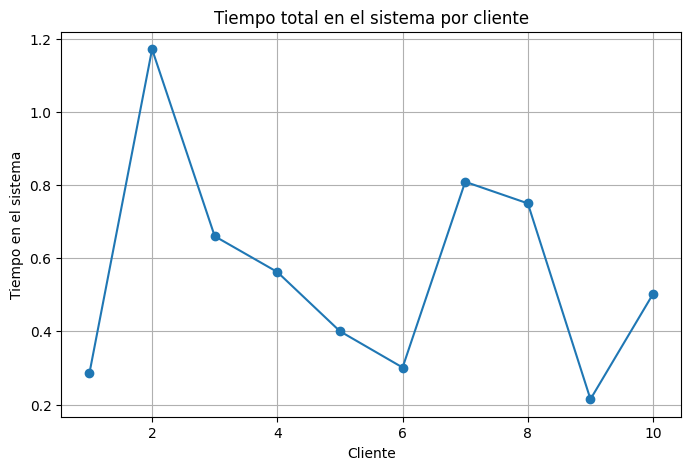

In [ ]:
#usamos las soguiente variables para Tiempo total en el sistema por cliente
clientes = list(T.keys())
tiempos = list(T.values())

plt.figure(figsize=(8,5))
plt.plot(clientes, tiempos, marker='o')
plt.xlabel('Cliente')
plt.ylabel('Tiempo en el sistema')
plt.title('Tiempo total en el sistema por cliente')
plt.grid(True)
plt.show()

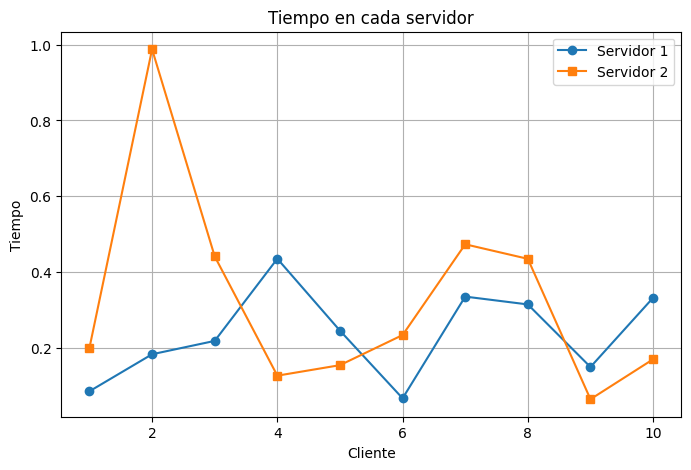

In [ ]:
clientes = list(W1.keys())

plt.figure(figsize=(8,5))
plt.plot(clientes, list(W1.values()),
         marker='o',
         label='Servidor 1')

plt.plot(clientes, list(W2.values()),
         marker='s',
         label='Servidor 2')

plt.xlabel('Cliente')
plt.ylabel('Tiempo')
plt.title('Tiempo en cada servidor')
plt.legend()
plt.grid(True)
plt.show()

Histograma del tiempo total en el sistema

La cual muestra la distribución de los tiempos.

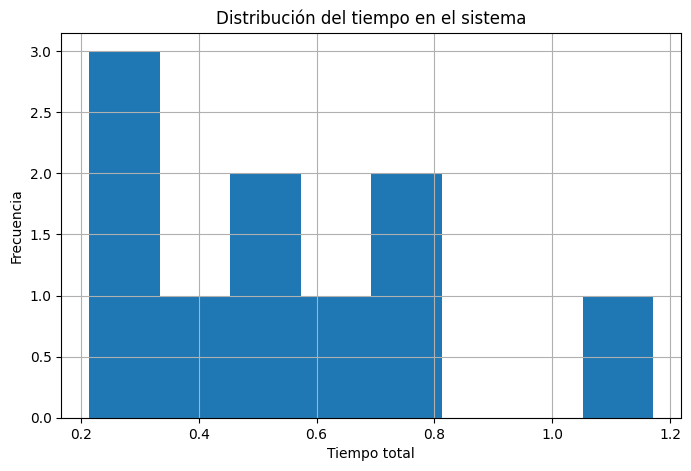

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(list(T.values()),
         bins=8)

plt.xlabel('Tiempo total')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo en el sistema')
plt.grid(True)

plt.show()

Las gráficas permiten observar cómo los clientes atraviesan los dos servidores y cuantificar el tiempo total que permanecen en el sistema. La comparación de los tiempos en cada servidor ayuda a detectar posibles cuellos de botella, mientras que el tiempo total por cliente refleja la variabilidad inherente del proceso estocástico. En conjunto, los resultados permiten evaluar la eficiencia del sistema y el impacto de las tasas de llegada y servicio sobre el desempeño de la fila.

# <span style="color:purple;">**Conclusión:** </span>

La simulación de un sistema de colas con dos servidores en serie permitió analizar el flujo de clientes a través de dos etapas consecutivas de servicio. Los resultados muestran que el tiempo total de permanencia de cada cliente depende tanto de los tiempos de servicio como de la congestión generada en cada servidor. Al comparar los tiempos en ambas etapas, es posible identificar si alguno de los servidores actúa como cuello de botella, provocando acumulación de clientes y aumentando los tiempos de espera. En general, la simulación evidencia cómo la variabilidad de las llegadas y de los servicios influye en el desempeño del sistema, proporcionando una herramienta útil para evaluar la eficiencia operativa y estudiar posibles mejoras en la capacidad de atención.

#  <span style="color:purple;">**6.4 Sistema de línea de espera con dos servidores en paralelo** (libro de Ross)</span>


<span style="color:teal;">**Objetivo:** </span> Simular un sistema de colas con dos servidores en paralelo para estudiar el flujo de clientes y evaluar la eficiencia del sistema mediante el análisis de tiempos de espera, tiempos de servicio y utilización de los servidores.

Consideremos un modelo en el que los clientes llegan a un sistema con dos servidores. Al llegar, un cliente se forma en una fila si ambos servidores están ocupados, entra a servicio con el servidor 1 si este servidor está desocupado, o bien con el servidor 2 en caso contrario. Cuando el cliente concluye el servicio con un servidor (sin importar cuál sea), sale del sistema y el cliente que ha estado formado más tiempo (si hay clientes en la cola) entra a servicio. La distribución de servicio en el servidor $i$ es $G_i$, $i = 1,2$ (véase la figura).

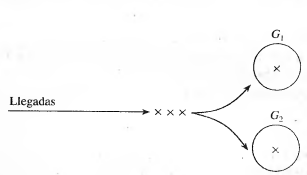

Suponga que queremos simular el modelo anterior manteniendo un registro de las cantidades de tiempo que pasa cada cliente dentro del sistema y el número de servicios realizados por cada servidor. Como hay varios servidores, los clientes no saldrán en el orden de llegada. Por lo tanto, para saber qué cliente deja el sistema al concluir su servicio, necesitamos llevar un registro para ver qué clientes están en el sistema. Así, los numeraremos conforme vayan llegando, de modo que el primero en llegar es el cliente número 1, el siguiente es el número 2, y así sucesivamente. Utilizaremos las siguientes variables:

* <span style="color:green;">**Variable de tiempo $t$**</span>

* <span style="color:green;">**Variable de estado del sistema (ES)**</span>

$$
(n,\, i_1,\, i_2,\, \ldots,\, i_s)
$$

si hay $n$ clientes en el sistema, $i_1$ está con el servidor 1,
$i_2$ está con el servidor 2, $i_3$ es el primero de la fila,
$i_4$ es el siguiente, y así sucesivamente.

Observe que

$$
ES=(0)
$$

cuando el sistema está vacío, y

$$
ES=(1,j,0)
$$

o

$$
(1,0,j)
$$

cuando el único cliente es $j$ y éste está siendo atendido por el
servidor 1 o el 2, respectivamente.

* <span style="color:green;">**Variables de conteo**</span>

* $N_A:$ el número de llegadas hasta el instante $t$

* $C_j:$ el número de clientes atendidos por $j$,

* $j=1,2$, hasta el instante $t$

* <span style="color:green;">**Variables de salida**</span>

* $A(n):$ la hora de llegada del cliente $n$, $n \geq 1$

* $D(n):$ la hora de salida del cliente $n$, $n \geq 1$

* <span style="color:green;">**Lista de eventos**</span>

$$
t_A,\; t_1,\; t_2
$$

Donde $t_A$ es la hora de la siguiente llegada y $t_j$ es la hora en la
que concluye el servicio del cliente que en ese momento está siendo
atendido por el servidor $j$, $j=1,2$. Si no hay un cliente actualmente
con el servidor $i$, entonces hacemos

$$
t_i=\infty, \qquad i=1,2.
$$

En lo sucesivo, la lista de eventos siempre constará de las tres
variables $t_A$, $t_1$, $t_2$.

Para comenzar la simulación, inicializamos las variables y la lista de
eventos como sigue:

* <span style="color:purple;">**Inicialización**</span>

Hacer

$$
t = N_A = C_1 = C_2 = 0.
$$

Hacer

$$
ES = (0).
$$

Generar $T_A$ y hacer

$$
t_A = T_A, \qquad t_1 = T_2 = \infty.
$$

Para actualizar el sistema, nos movemos en el tiempo hasta encontrar el
siguiente evento. En los siguientes casos, $Y_i$ siempre se refiere a una
variable aleatoria con distribución $G_i$, $i=1,2$.



1. <span style="color:purple;">**Caso 1**</span>

$$
ES=(n,i_1,i_2,\ldots,i_n)
$$

y

$$
t_A=\min(t_A,t_1,t_2)
$$

Restablecer:

$$
t=t_A.
$$

Restablecer:

$$
N_A=N_A+1.
$$

Generar $T_A$ y hacer

$$
t_A=t+T_A.
$$

Reunir los datos de salida

$$
A(N_A)=t.
$$



Si

$$
ES=(0):
$$

$$
ES=(1,N_A,0).
$$

Generar $Y_1$ y hacer

$$
t_1=t+Y_1.
$$



Si

$$
ES=(1,j,0):
$$

Restablecer:

$$
ES=(2,j,N_A).
$$

Generar $Y_2$ y hacer

$$
t_2=t+Y_2.
$$



Si

$$
ES=(1,0,j):
$$

Restablecer:

$$
ES=(2,N_A,j).
$$

Generar $Y_1$ y hacer

$$
t_1=t+Y_1.
$$



Si

$$
n>1:
$$

Restablecer:

$$
ES=(n+1,i_1,\ldots,i_n,N_A).
$$


2. <span style="color:purple;">**Caso 2**</span>

$$
ES=(n,i_1,i_2,\ldots,i_n)
$$

y

$$
t_1<t_A \quad \text{y} \quad t_1\leq t_2
$$

Restablecer:

$$
t=t_1.
$$

Restablecer:

$$
C_1=C_1+1.
$$

Reunir los datos de salida

$$
D(i_1)=t.
$$



Si

$$
n_1=1:
$$

Restablecer:

$$
ES=(0).
$$

Restablecer:

$$
t_1=\infty.
$$



Si

$$
n_1=2:
$$

Restablecer:

$$
ES=(1,0,i_2).
$$

Restablecer:

$$
t_1=\infty.
$$



Si

$$
n > 2:
$$

Restablecer:

$$
ES=(n-1,i_3,i_2,\ldots,i_n).
$$

Generar $Y_1$ y hacer

$$
t_1=t+Y_1.
$$



3. <span style="color:purple;">**Caso 3**</span>

$$
ES=(n,i_1,i_2,\ldots,i_n)
$$

y

$$
t_2<t_A,\quad t_2<t_1.
$$

Las actualizaciones en el caso 3 se dejan como ejercicio.



Si simulamos el sistema de acuerdo con lo anterior y detenemos la
simulación en algún punto final determinado de antemano, entonces
podemos utilizar las variables de salida, al igual que los valores
finales de las variables de conteo $C_1$ y $C_2$ para obtener los
datos relativos a las horas de llegada y salida de los diversos
clientes, así como el número de servicios de cada servidor.

In [ ]:
# SISTEMA DE COLAS CON DOS SERVIDORES EN PARALELO
# Simulación por eventos discretos
import numpy as np
from collections import deque # Sirve para importar la estructura de datos deque (double-ended queue o cola de doble extremo) del módulo collections
import matplotlib.pyplot as plt

Generamos los tiempos aleatorios igual que el programa suponemos que:
* Llegadas $~$ Exponencial($λ$)

* Servicio 1 $~$ Exponencial($μ₁$)

* Servicio 2 $~$ Exponencial($μ₂$)

In [ ]:
def generar_llegada(lamb):
    """
    Genera el tiempo entre llegadas.
    TA ~ Exponencial(lambda)
    """
    return np.random.exponential(1 / lamb)

In [ ]:
def generar_servicio1(mu1):
    """
    Tiempo de servicio del servidor 1.
    Y1 ~ Exponencial(mu1)
    """
    return np.random.exponential(1 / mu1)

In [ ]:
def generar_servicio2(mu2):
    """
    Tiempo de servicio del servidor 2.
    Y2 ~ Exponencial(mu2)
    """
    return np.random.exponential(1 / mu2)

Creamos la función para simular un sistema de colas con dos servidores en paralelo con:

Parámetros

* lamb : tasa de llegadas
*   mu1  : tasa de servicio servidor 1
* mu2  : tasa de servicio servidor 2
* n_clientes : número de clientes a completar

Retorna

* A : tiempos de llegada
* D : tiempos de salida
* C1: servicios realizados por servidor 1
* C2: servicios realizados por servidor 2


In [ ]:
def simular_dos_servidores( lamb, mu1, mu2, n_clientes):
      # t = NA = C1 = C2 = 0
    t = 0.0
    NA = 0
    C1 = 0
    C2 = 0
    # ES = (0)
    cola = deque() #crea una cola (fila) vacía.
    servidor1 = None
    servidor2 = None
    # Generar TA
    TA = generar_llegada(lamb)
    tA = TA
    t1 = np.inf
    t2 = np.inf
    # Datos de salida
    A = {}
    D = {}
    # Historial para N(t)
    tiempos = [0]
    clientes_sistema = [0]
    n_sistema = 0
    while len(D) < n_clientes:
        minimo = min(tA, t1, t2)
        # Caso 1 llegada
        if minimo == tA:
            t = tA
            NA += 1
            cliente = NA
            A[cliente] = t
            n_sistema += 1
            tiempos.append(t)
            clientes_sistema.append(n_sistema)
            # Nueva llegada
            TA = generar_llegada(lamb)
            tA = t + TA
            # Indica si el sistema esta vacío
            if servidor1 is None and servidor2 is None:
                servidor1 = cliente
                Y1 = generar_servicio1(mu1)
                t1 = t + Y1
            # Servidor 1 ocupado y servidor 2 libre
            elif servidor1 is not None and servidor2 is None:
                servidor2 = cliente
                Y2 = generar_servicio2(mu2)
                t2 = t + Y2
            else:
                cola.append(cliente) #guarda en la lista
        # CASO 2: Salida servidor 1
        elif minimo == t1:
            t = t1
            C1 += 1
            cliente = servidor1
            D[cliente] = t
            n_sistema -= 1
            tiempos.append(t)
            clientes_sistema.append(n_sistema)
            # Hay clientes esperando
            if len(cola) > 0:
                servidor1 = cola.popleft()
                Y1 = generar_servicio1(mu1)
                t1 = t + Y1
            # No hay clientes esperando
            else:
                servidor1 = None
                t1 = np.inf
        # CASO 3: Salida servidor 2
        else:
            t = t2
            C2 += 1
            cliente = servidor2
            D[cliente] = t
            n_sistema -= 1
            tiempos.append(t)
            clientes_sistema.append(n_sistema)
            # Hay clientes esperando
            if len(cola) > 0:
                servidor2 = cola.popleft()
                Y2 = generar_servicio2(mu2)
                t2 = t + Y2
            # No hay clientes esperando
            else:
                servidor2 = None
                t2 = np.inf
      #resultados
    return A, D, C1, C2, tiempos, clientes_sistema

Resultados para Linea de espera de dos servidores en paralelo

In [ ]:
np.random.seed(123) #Fijamos la misma semilla anterior
A, D, C1, C2, tiempos, clientes_sistema = simular_dos_servidores( lamb=2,mu1=3,mu2=4,n_clientes=20)

In [ ]:
print("Llegadas")
for k, v in A.items():
    print(k, round(v,4))

Llegadas
1 0.5961
2 0.7647
3 1.1654
4 1.4404
5 2.0178
6 2.3456
7 2.9985
8 3.0293
9 3.699
10 3.7954
11 4.1749
12 5.1216
13 5.5937
14 5.7887
15 5.9183
16 6.4167
17 6.701
18 7.0413
19 7.2285
20 8.3478


In [ ]:
print("\nSalidas")
for k, v in D.items():
    print(k, round(v,4))


Salidas
1 0.6819
2 1.1884
3 2.1531
4 2.2776
5 2.3827
6 2.527
8 3.0797
7 3.1677
9 3.9518
10 4.047
11 4.6046
12 5.5488
13 5.7434
14 5.9046
15 5.9505
16 6.6046
17 6.886
18 7.2266
19 8.1903
20 8.6738


Observemos cuantos servicios realizo cada servidor

In [ ]:
print("\nServicios realizados")
print("Servidor 1 =", C1)
print("Servidor 2 =", C2)


Servicios realizados
Servidor 1 = 14
Servidor 2 = 6


Calculamos los estadísticos:

* Tiempo total en el sistema

In [ ]:
T = {} #lista vacía para almacenar los tiempos
for cliente in D:
    T[cliente] = D[cliente] - A[cliente]
print(
    "\nTiempo promedio en sistema:",
    np.mean(list(T.values()))) #Calculamos el promedio


Tiempo promedio en sistema: 0.33025315642551933


Graficamente lo que observamos es lo siguiente:

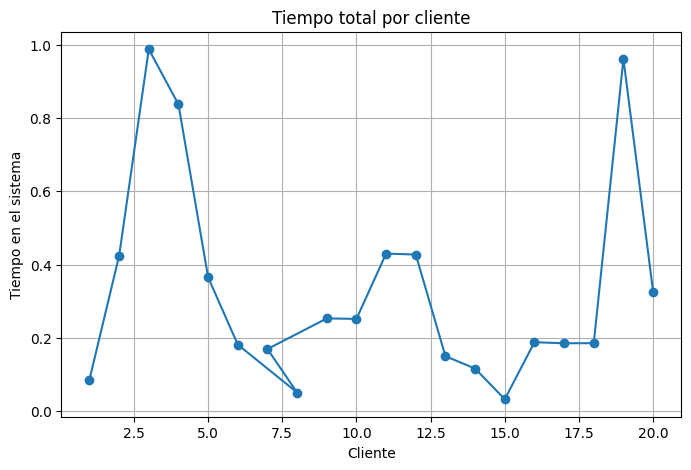

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    list(T.keys()),
    list(T.values()),
    marker='o'
)
plt.xlabel("Cliente")
plt.ylabel("Tiempo en el sistema")
plt.title("Tiempo total por cliente")
plt.grid(True)
plt.show()

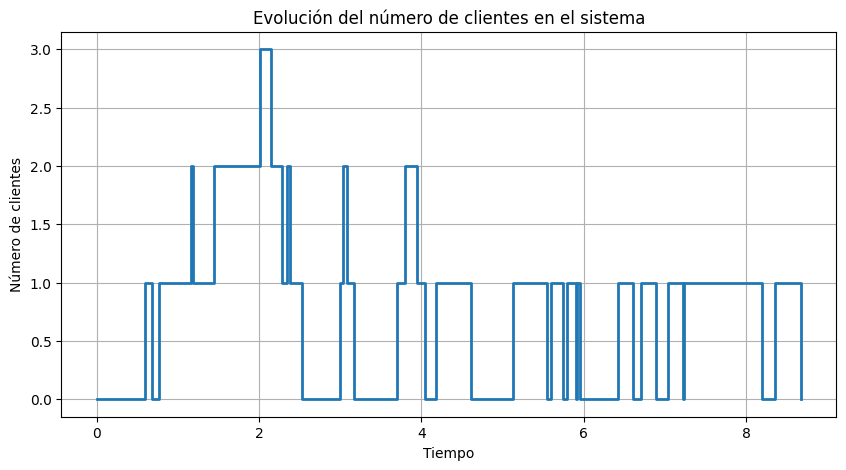

In [ ]:
plt.figure(figsize=(10,5))
plt.step(
    tiempos,
    clientes_sistema,
    where='post',
    linewidth=2
)
plt.xlabel('Tiempo')
plt.ylabel('Número de clientes')
plt.title('Evolución del número de clientes en el sistema')

plt.grid(True)
plt.show()

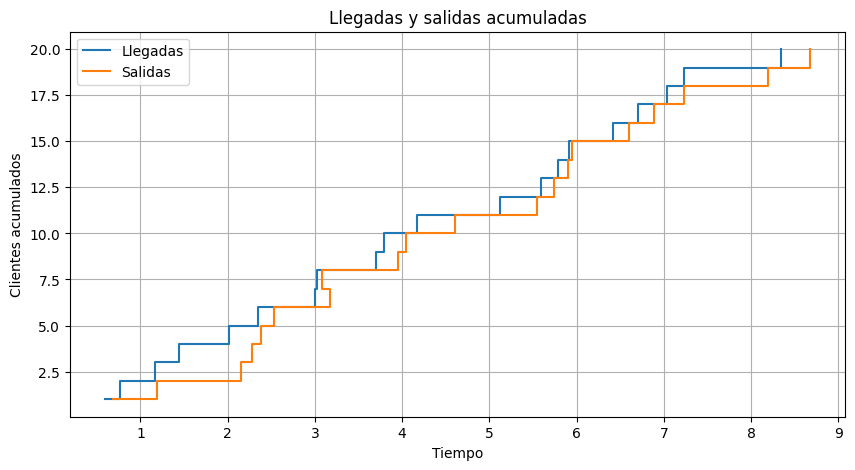

In [ ]:
clientes_A = sorted(A.keys())
clientes_D = sorted(D.keys())
tiempos_A = [A[i] for i in clientes_A]
tiempos_D = [D[i] for i in clientes_D]
plt.figure(figsize=(10,5))
plt.step(
    tiempos_A,
    clientes_A,
    where='post',
    label='Llegadas'
)
plt.step(
    tiempos_D,
    clientes_D,
    where='post',
    label='Salidas'
)
plt.xlabel('Tiempo')
plt.ylabel('Clientes acumulados')
plt.title('Llegadas y salidas acumuladas')
plt.legend()
plt.grid(True)
plt.show()

<span style="color:purple;">**Interpretación de las gráficas**</span>

* **Número de clientes en el sistema $N(t)$:**

  * Cada salto hacia arriba representa una llegada.

  * Cada salto hacia abajo representa una salida.

  * Los valores altos indican congestión.

* **Llegadas y salidas acumuladas:**

  * La distancia vertical entre ambas curvas representa aproximadamente el número de clientes presentes en el sistema.

  * Si las curvas están muy separadas, existe acumulación de clientes.

  * Si las curvas son cercanas, el sistema atiende eficientemente la demanda.

## <span style="color:magenta;">**Conclusión**</span>

La simulación permite analizar cómo los clientes son distribuidos entre dos servidores que trabajan simultáneamente. La presencia de servidores paralelos reduce la congestión y mejora la capacidad de atención respecto a un sistema con un solo servidor. A partir de los tiempos de llegada y salida es posible evaluar la eficiencia del sistema, identificar periodos de acumulación de clientes y comparar la carga de trabajo entre ambos servidores.